## Using the Gym Members Exercise Dataset — Project Summary

**Goal:** The goal of this project is to predict `Calories_Burned` for individual gym sessions using demographic, physiological, and workout behavior features. We evaluate multiple regression models to identify the best-performing approach and extract actionable insights for trainers and fitness applications.

**Data Problem:** Train and tune multiple regression models to predict a continuous target (`Calories_Burned`) from structured session and member features. Compare model performance using cross-validation and interpret the most important features.

**Expected Results:** A reliable predictive model (or ensemble) with low MSE and high R² on held-out data. We will report cross-validated metrics and identify the features that most influence calorie predictions.

**Analysis & Interpretation:** We will perform global interpretability (feature importances, permutation importance) and local interpretability (example-level explanations) to surface which features (e.g., `Session_Duration (hours)`, `Avg_BPM`, `Workout_Type`) most strongly drive predictions. Recommended tools for interpretation include `sklearn` feature importance, permutation importance, and model-agnostic explainers such as `eli5` or `shap`.

### Data

- Source: Kaggle — Gym Members Exercise Dataset
- Local file: `data/gym_members_exercise_tracking.csv`
- Notes: dataset contains session-level records from gym users (demographics, BPM, duration, workout type, calories burned). Ensure data privacy and responsible handling when working with user-level information.

https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset?resource=download
The dataset contains 973 records of gym members with demographic, physiological, and workout-related variables

### Modeling Approach (high level)

- Baseline models: LinearRegression, Ridge, Lasso
- Nonlinear/tree-based models: RandomForestRegressor, GradientBoostingRegressor (tuned with GridSearchCV)
- Evaluation: 5-fold cross-validation reporting MSE (use `neg_mean_squared_error` in sklearn scorers) and R²
- Interpretation: permutation importance, partial dependence plots, and inspection of feature contributions for selected examples.

### Ethical considerations

- When sharing or deploying predictive models that use individual-level workout data, respect user privacy and avoid exposing personally identifiable information. Present predictions as estimates and provide transparency about model uncertainty.

### Deliverables

- A Jupyter Notebook (`gym_member_exercise.ipynb`) with EDA, preprocessing, modeling, hyperparameter tuning, and interpretation sections.
- A README summary (this file) with cross-validated metrics, tuned model results, and key recommendations for stakeholders.


In [405]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score

### Load Dataset

In [381]:
#load dataset
df = pd.read_csv("data/gym_members_exercise_tracking.csv")
print("Shape:", df.shape)
df.head()

Shape: (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### EDA (Exploratory Data Analysis)

In [382]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [383]:
#check duplicates and missing data
df.info()

# Drop duplicates
df = df.drop_duplicates()

# Check missingness
missing = df.isnull().mean().sort_values(ascending=False)
print("Missing fraction (top):")
print(missing.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [384]:
# create new features

# Age groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

# BPM-Duration Index
df["BPM_Duration_Index"] = df["Avg_BPM"] * df["Session_Duration (hours)"]

# Workout Intensity score
df["Intensity"] = df["Avg_BPM"] / df["Session_Duration (hours)"]

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Age_Group,BPM_Duration_Index,Intensity
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,56-65,265.33,92.899408
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,46-55,196.30,116.153846
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,26-35,135.42,109.909910
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,18-25,96.76,277.966102
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,36-45,101.12,246.875000


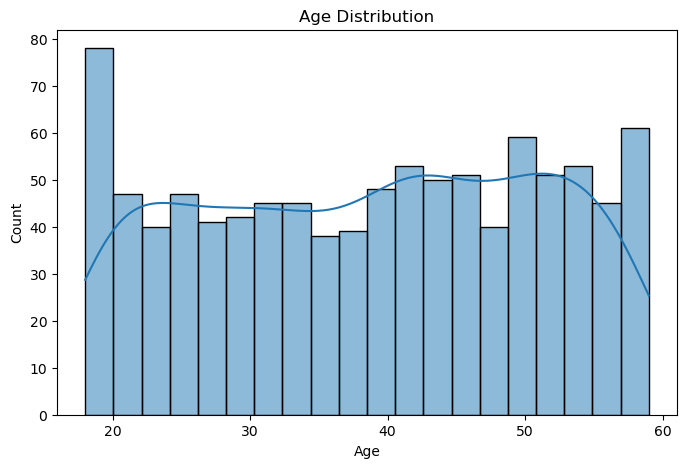

In [385]:
# Visualize age distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

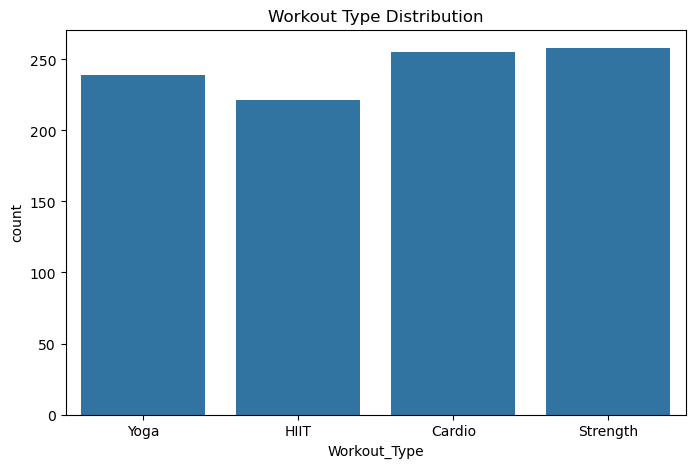

In [386]:
# Visualize workout type distribution

plt.figure(figsize=(8,5))
sns.countplot(x="Workout_Type", data=df)
plt.title("Workout Type Distribution")
plt.show()


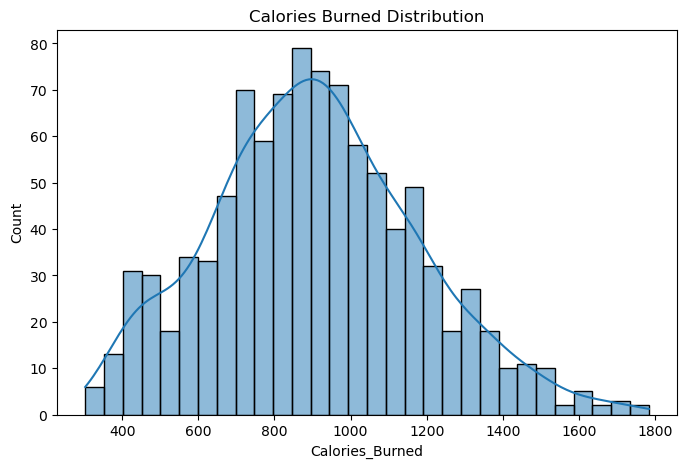

In [387]:
# Visualize calories burned distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Calories_Burned"], bins=30, kde=True)
plt.title("Calories Burned Distribution")
plt.show()

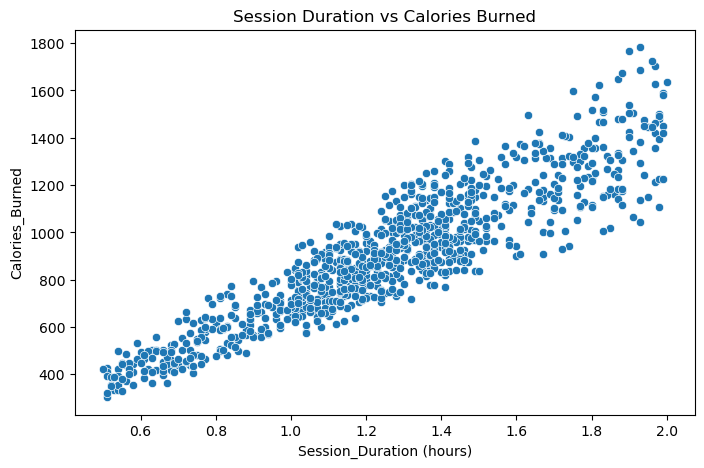

In [388]:
# Visualize session duration vs calories burned
#df.info()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Session_Duration (hours)", y="Calories_Burned", data=df)
plt.title("Session Duration vs Calories Burned")
plt.show()

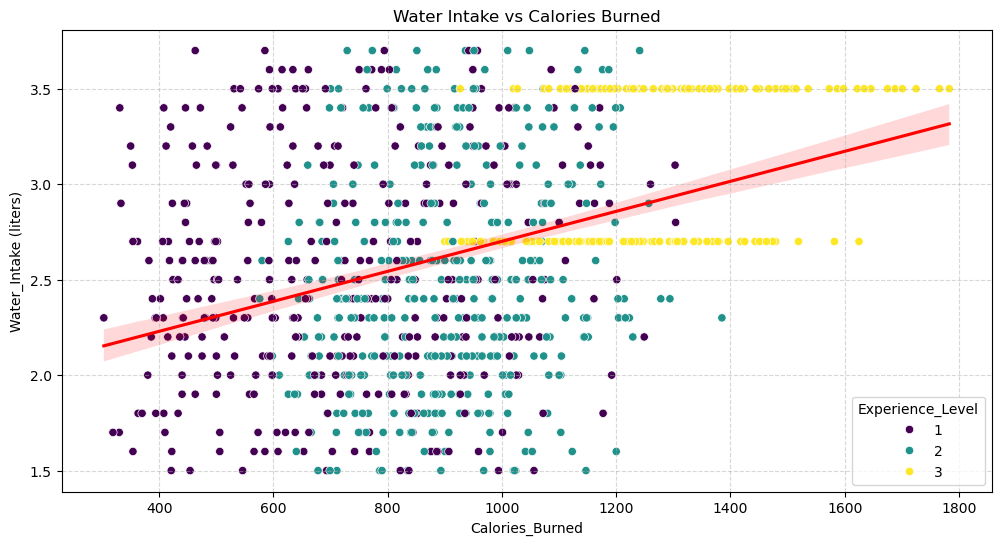

In [402]:
# Water Intake Analysis vs. Calories Burned
#Set up the matplotlib figure
plt.figure(figsize=(12, 6))

# Plot the water intake vs calories burned
sns.scatterplot(data=df, x='Calories_Burned', y='Water_Intake (liters)', hue='Experience_Level', palette='viridis')
plt.title('Water Intake vs Calories Burned')
plt.xlabel('Calories Burned')
plt.ylabel('Water Intake (liters)')

# Add trendline
sns.regplot(data=df, x='Calories_Burned', y='Water_Intake (liters)', scatter=False, color='red')

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.show()

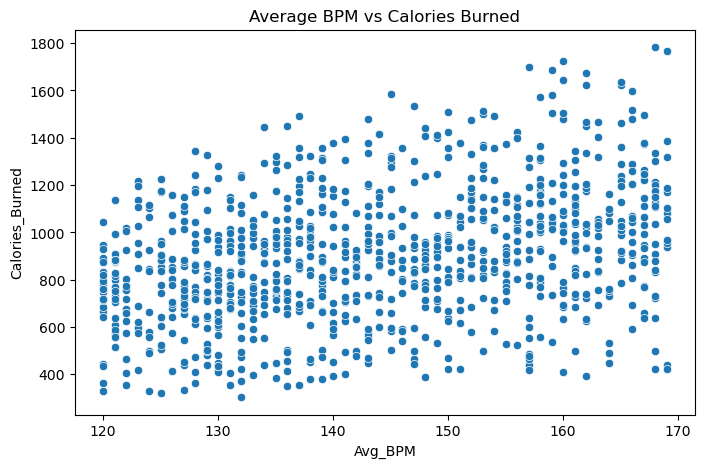

In [389]:
# Visualize average BPM vs calories burned

plt.figure(figsize=(8,5))
sns.scatterplot(x="Avg_BPM", y="Calories_Burned", data=df)
plt.title("Average BPM vs Calories Burned")
plt.show()

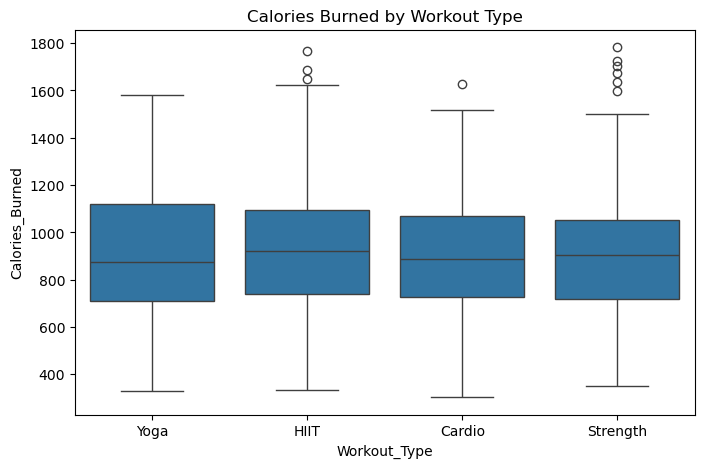

In [390]:
# Visualize calories burned by workout type

plt.figure(figsize=(8,5))
sns.boxplot(x="Workout_Type", y="Calories_Burned", data=df)
plt.title("Calories Burned by Workout Type")
plt.show()

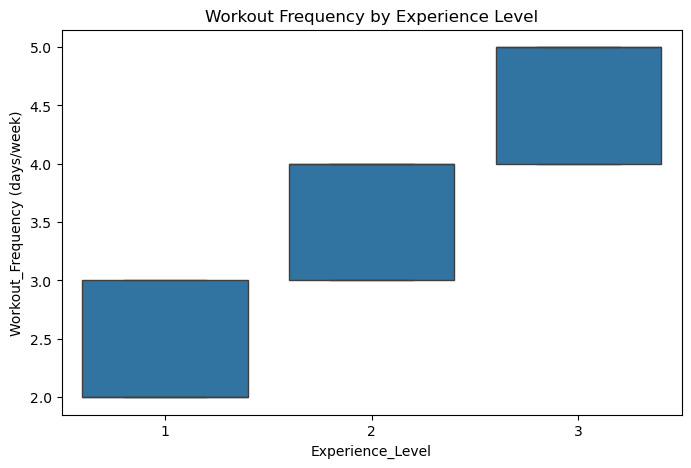

In [391]:
# Visualize workout frequency by experience level

plt.figure(figsize=(8,5))
sns.boxplot(x="Experience_Level", y="Workout_Frequency (days/week)", data=df)
plt.title("Workout Frequency by Experience Level")
plt.show()

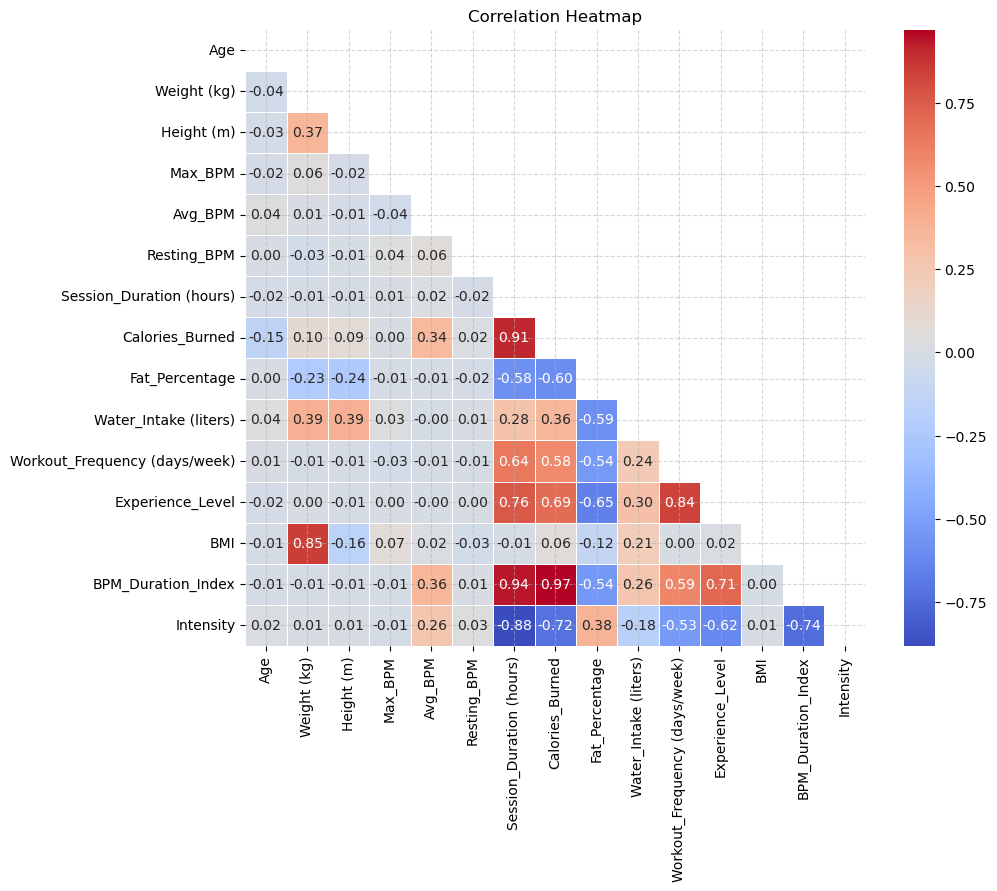

In [403]:
# Correlation heatmap  

plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, mask=np.triu(corr))
plt.title("Correlation Heatmap")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

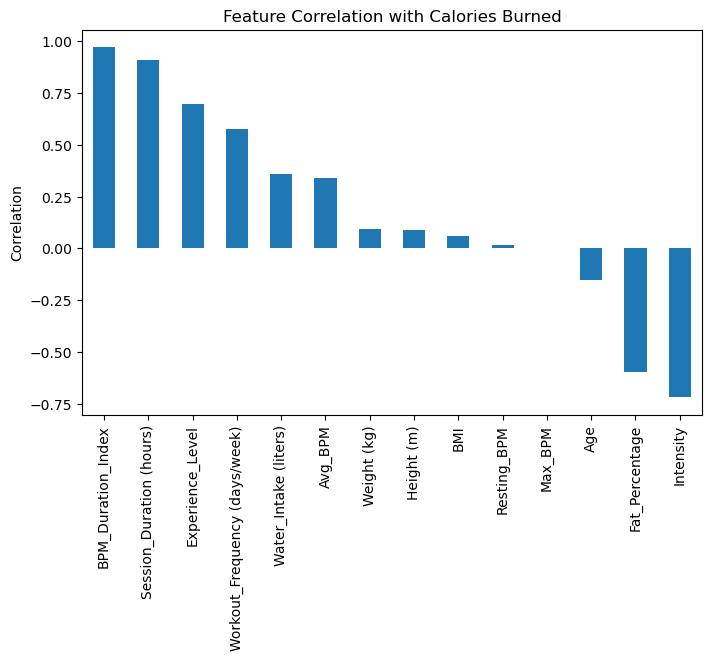

In [394]:
# Correlation with target variable
#top features correlated with calories burned

corr_target = corr["Calories_Burned"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr_target.drop("Calories_Burned").plot(kind="bar")
plt.title("Feature Correlation with Calories Burned")
plt.ylabel("Correlation")
plt.show()

EDA Conclusion:
- Session duration and average BPM are the strongest predictors of calories burned.
- HIIT and cardio workouts produce higher calorie expenditure.
- Experience level is associated with higher workout frequency.
- Dataset shows realistic physiological relationships suitable for regression modeling.

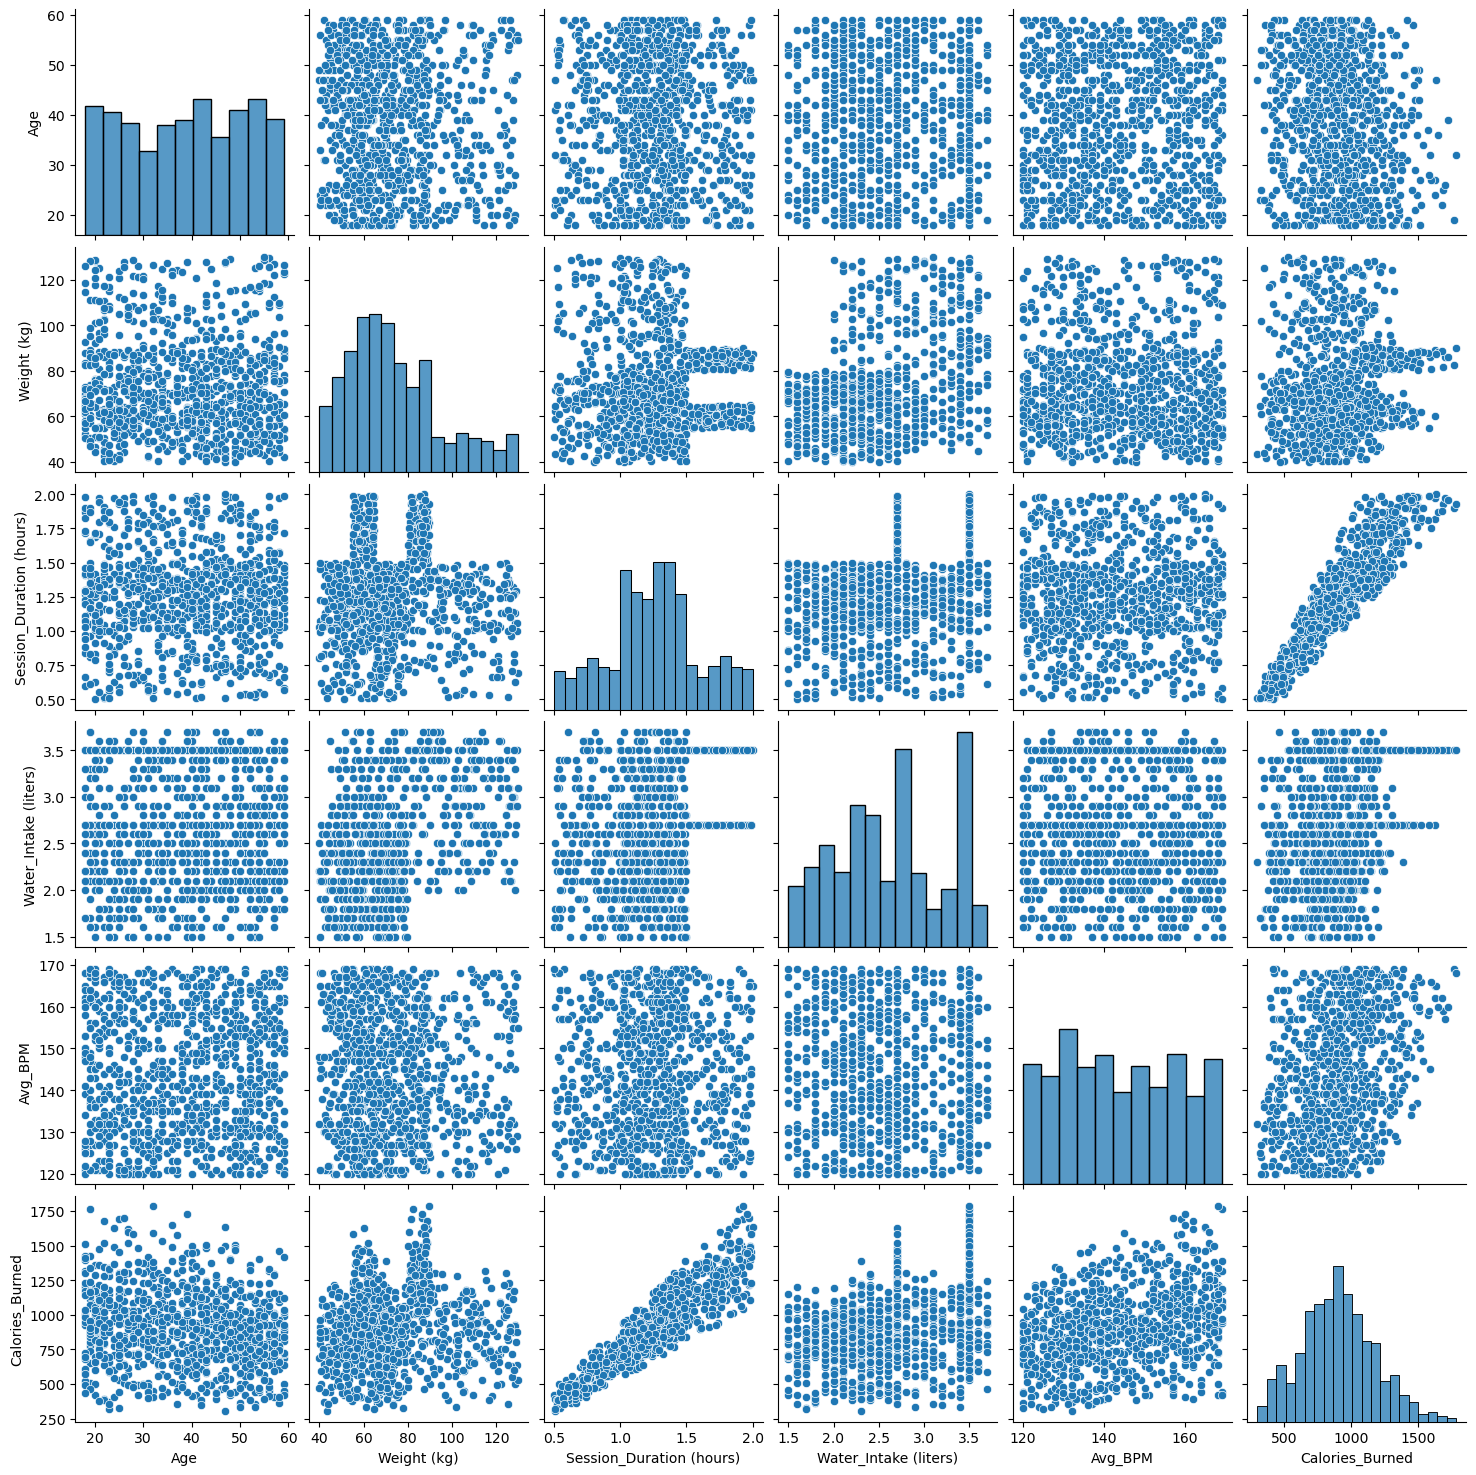

In [404]:
sns.pairplot(df[[
    "Age",
    "Weight (kg)",
    "Session_Duration (hours)",
    "Water_Intake (liters)",
    "Avg_BPM",
    "Calories_Burned"
]])

### Splitting the Data Set

In [396]:
# Train-test split
X = df.drop(columns=["Calories_Burned"])
y = df["Calories_Burned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (778, 17) Test: (195, 17)


In [397]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Numeric features: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'BPM_Duration_Index', 'Intensity']
Categorical features: ['Gender', 'Workout_Type', 'Age_Group']


In [398]:
# Linear Regression
pipe = Pipeline(steps=[("preprocess", preprocess),
                          ("model", LinearRegression())])
pipe.fit(X_train, y_train)

preds = pipe.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

MSE: 829.2024522364196
R²: 0.9900605070736874


In [406]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "RandomForest": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1,
        max_depth=None, min_samples_split=2, min_samples_leaf=1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

cv_results = []
mse_values = []
r2_values = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess),
                          ("model", model)])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    cv_results.append((name, mse, r2))
    mse_values.append(mse)
    r2_values.append(r2)
results_df = pd.DataFrame(cv_results, columns=["Model", "CV_MSE", "CV_R2"]).sort_values("CV_MSE")
results_df


,Model,CV_MSE,CV_R2
6,GradientBoosting,118.756340,0.998576
5,RandomForest,484.346195,0.994194
1,DecisionTreeRegressor,673.630769,0.991925
3,Lasso,829.172143,0.990061
0,LinearRegression,829.202452,0.990061
2,Ridge,853.381660,0.989771
4,KNN,7468.796023,0.910473


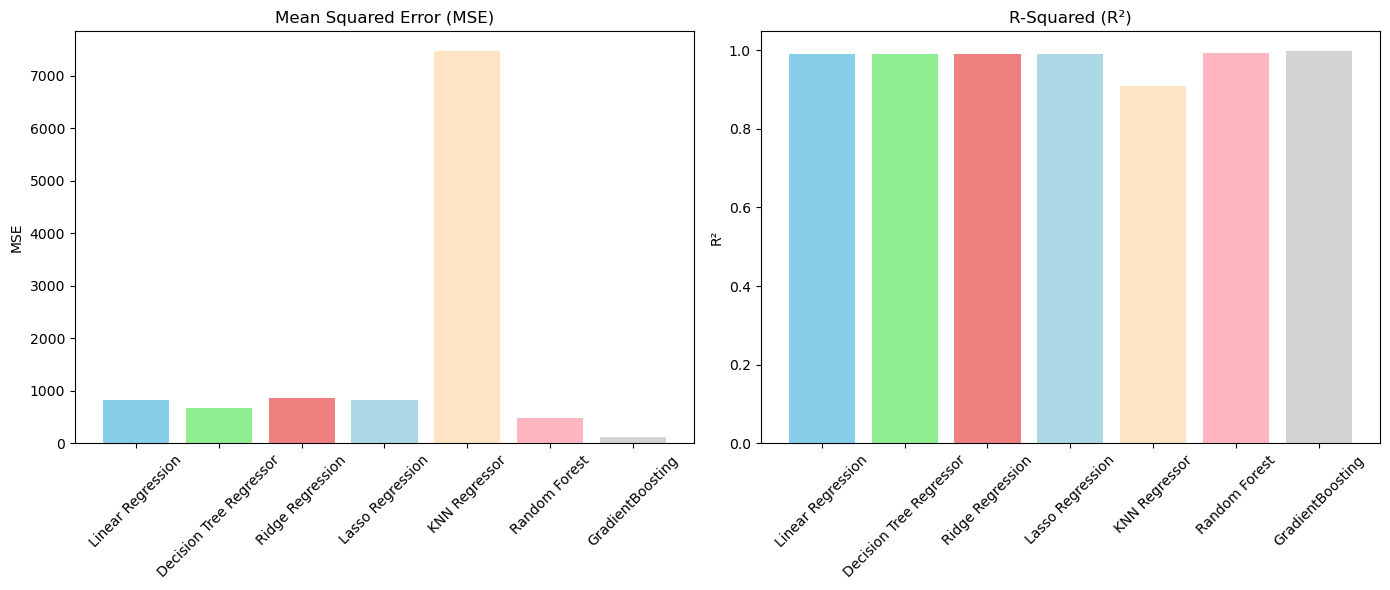

In [407]:
# Visualize predicted vs actual for best model
models = ['Linear Regression','Decision Tree Regressor','Ridge Regression','Lasso Regression','KNN Regressor','Random Forest','GradientBoosting']

plt.figure(figsize=(14,6))

# MSE Bar Plot
plt.subplot(1, 2, 1)
plt.bar(models, mse_values, color=['skyblue', 'lightgreen', 'lightcoral', 'lightblue', 'bisque', 'lightpink', 'lightgray'])
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks(rotation=45)

# R-Squared Bar Plot
plt.subplot(1, 2, 2)
plt.bar(models, r2_values, color=['skyblue', 'lightgreen', 'lightcoral', 'lightblue', 'bisque', 'lightpink', 'lightgray'])
plt.title('R-Squared (R²)')
plt.ylabel('R²')
plt.xticks(rotation=45)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

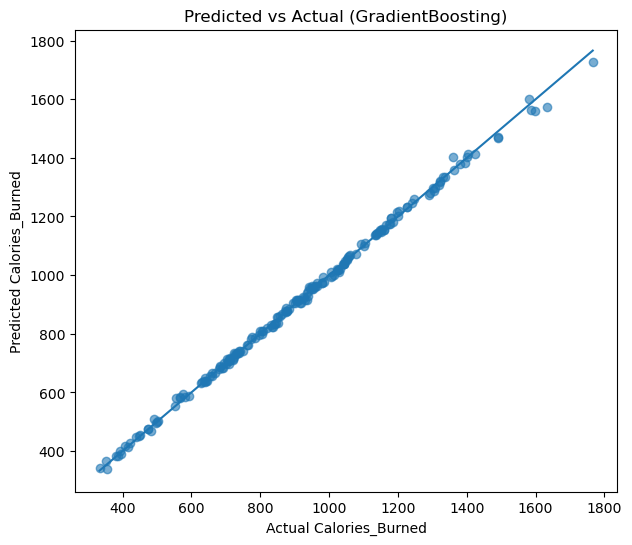

In [408]:
# Visualize predicted vs actual for best model

plt.figure(figsize=(7,6))
plt.scatter(y_test, preds, alpha=0.6)
plt.title(f"Predicted vs Actual ({results_df.iloc[0]['Model']})")
plt.xlabel("Actual Calories_Burned")
plt.ylabel("Predicted Calories_Burned")

# 45-degree reference line
minv = min(y_test.min(), preds.min())
maxv = max(y_test.max(), preds.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()

In [409]:
# Grid search + cross-validation for top 3 models

rf_grid = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': [1, 2, 4],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}
gb_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5],
}

dc_grid = {
    'model__criterion' : ['squared_error', 'absolute_error', 'poisson'],
    'model__splitter' : ['best', 'random'],
    'model__max_depth' : [2, 4, 8, 16, 32],
    'model__min_samples_split' : [2, 4, 8, 10, 16]
}

grids = {
    'RandomForest': (RandomForestRegressor(random_state=42), rf_grid),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), gb_grid),
    'DecisionTreeRegressor':(DecisionTreeRegressor(random_state=42),dc_grid)
}

best_results = []
for name, (model, grid) in grids.items():
    print(model)
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    gs = GridSearchCV(pipe, grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    print('Running GridSearch for', name)
    gs.fit(X_train, y_train)
    best_mse = -gs.best_score_
    best_r2 = cross_val_score(gs.best_estimator_, X_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
    print(f'{name} best params: {gs.best_params_} -- CV_MSE: {best_mse:.3f} -- CV_R2: {best_r2:.3f}')
    best_results.append((name, best_mse, best_r2, gs.best_params_))

best_df = pd.DataFrame(best_results, columns=['Model', 'Tuned_CV_MSE', 'Tuned_CV_R2', 'Best_Params']).sort_values('Tuned_CV_MSE')
best_df

RandomForestRegressor(random_state=42)
Running GridSearch for RandomForest
RandomForest best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 500} -- CV_MSE: 2315.150 -- CV_R2: 0.967
GradientBoostingRegressor(random_state=42)
Running GridSearch for GradientBoosting
GradientBoosting best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 200} -- CV_MSE: 179.832 -- CV_R2: 0.997
DecisionTreeRegressor(random_state=42)
Running GridSearch for DecisionTreeRegressor
DecisionTreeRegressor best params: {'model__criterion': 'poisson', 'model__max_depth': 16, 'model__min_samples_split': 2, 'model__splitter': 'best'} -- CV_MSE: 1163.660 -- CV_R2: 0.984


,Model,Tuned_CV_MSE,Tuned_CV_R2,Best_Params
1,GradientBoosting,179.832458,0.997436,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,DecisionTreeRegressor,1163.660066,0.983855,"{'model__criterion': 'poisson', 'model__max_de..."
0,RandomForest,2315.150297,0.967408,"{'model__max_depth': None, 'model__max_feature..."
